In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()


Saving sp500_historical_prices.csv to sp500_historical_prices.csv


In [ ]:
import io


df = pd.read_csv(io.BytesIO(uploaded['sp500_historical_prices.csv']))


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



data = pd.read_csv(io.BytesIO(uploaded['sp500_historical_prices.csv']))


data['Date'] = pd.to_datetime(data['Date'])

# Splitting data into training and test sets
training_data = data[data['Date'] <= '2022-12-31']
test_data = data[data['Date'] >= '2023-01-01']

# Calculating statistics for training data
training_min = training_data['Close'].min()
training_max = training_data['Close'].max()
training_mean = training_data['Close'].mean()
training_median = training_data['Close'].median()
training_std = training_data['Close'].std()
training_count = len(training_data)

# Calculating statistics for test data
test_min = test_data['Close'].min()
test_max = test_data['Close'].max()
test_mean = test_data['Close'].mean()
test_median = test_data['Close'].median()
test_std = test_data['Close'].std()
test_count = len(test_data)

# Displaying statistics
print("Training Data Statistics:")
print(f"Minimum: {training_min}")
print(f"Maximum: {training_max}")
print(f"Mean: {training_mean}")
print(f"Median: {training_median}")
print(f"Standard Deviation: {training_std}")
print(f"Number of Observations: {training_count}\n")

print("Test Data Statistics:")
print(f"Minimum: {test_min}")
print(f"Maximum: {test_max}")
print(f"Mean: {test_mean}")
print(f"Median: {test_median}")
print(f"Standard Deviation: {test_std}")
print(f"Number of Observations: {test_count}\n")




Training Data Statistics:
Minimum: 676.530029296875
Maximum: 4796.56005859375
Mean: 2076.6190637753934
Median: 1805.81005859375
Standard Deviation: 995.9000669696311
Number of Observations: 4531

Test Data Statistics:
Minimum: 3808.10009765625
Maximum: 4927.93017578125
Mean: 4322.151969401041
Median: 4332.830078125
Standard Deviation: 260.75986545113665
Number of Observations: 270



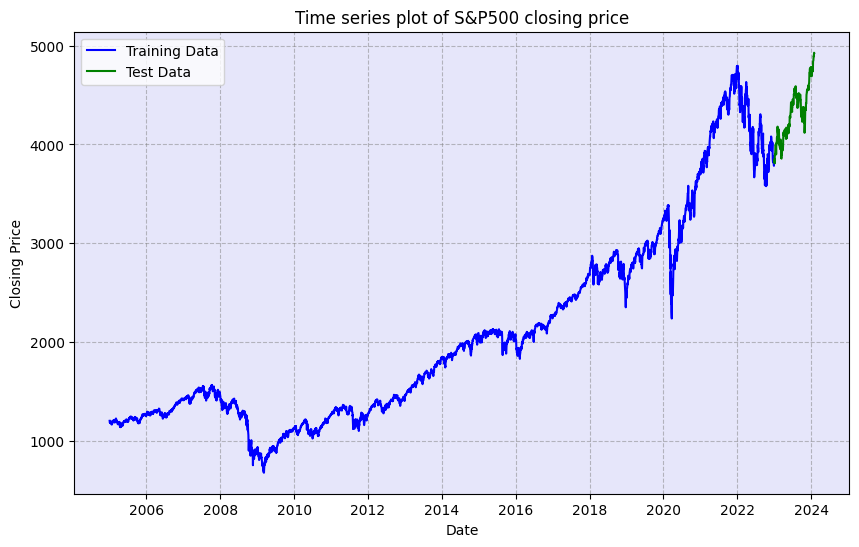

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



data = pd.read_csv(io.BytesIO(uploaded['sp500_historical_prices.csv']))


data['Date'] = pd.to_datetime(data['Date'])

# Splitting data into training and test sets
training_data = data[data['Date'] <= '2022-12-31']
test_data = data[data['Date'] >= '2023-01-01']

# Plotting Closing Prices for both training and test data
plt.figure(figsize=(10, 6))
plt.plot(training_data['Date'], training_data['Close'], label='Training Data', color='blue')
plt.plot(test_data['Date'], test_data['Close'], label='Test Data', color='green')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Time series plot of S&P500 closing price')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.5, color='gray')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.gca().set_facecolor('#E6E6FA')
plt.show()


Artificial Neural Network

Epoch 1/100
114/114 [==============================] - 1s 3ms/step - loss: 3074844.0000 - val_loss: 14108372.0000
Epoch 2/100
114/114 [==============================] - 0s 1ms/step - loss: 3008765.5000 - val_loss: 13682065.0000
Epoch 3/100
114/114 [==============================] - 0s 2ms/step - loss: 2780298.0000 - val_loss: 12590808.0000
Epoch 4/100
114/114 [==============================] - 0s 2ms/step - loss: 2328410.2500 - val_loss: 10724402.0000
Epoch 5/100
114/114 [==============================] - 0s 2ms/step - loss: 1687091.6250 - val_loss: 8289845.0000
Epoch 6/100
114/114 [==============================] - 0s 2ms/step - loss: 1009132.6875 - val_loss: 5774442.0000
Epoch 7/100
114/114 [==============================] - 0s 2ms/step - loss: 493730.4688 - val_loss: 3780286.7500
Epoch 8/100
114/114 [==============================] - 0s 2ms/step - loss: 228881.7188 - val_loss: 2564515.5000
Epoch 9/100
114/114 [==============================] - 0s 1ms/step - loss: 142950.2656 - val_l

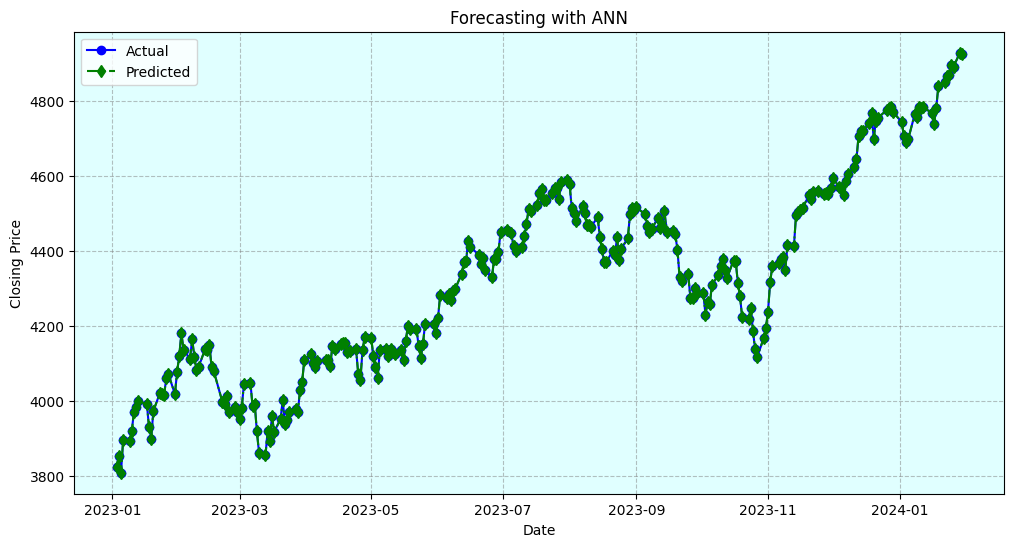

In [ ]:
!pip install tensorflow scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, mean_squared_log_error, r2_score
from sklearn.metrics import mean_squared_log_error, mean_squared_log_error, mean_squared_log_error


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


data = pd.read_csv(io.BytesIO(uploaded['sp500_historical_prices.csv']))
data['Date'] = pd.to_datetime(data['Date'])

# Extract training and test data
train_data = data[(data['Date'] >= "2005-01-01") & (data['Date'] <= "2022-12-31")]
test_data = data[(data['Date'] >= "2023-01-01") & (data['Date'] <= "2024-01-31")]

# Select the closing price as the target variable
train_target = train_data['Close'].values.reshape(-1, 1)
test_target = test_data['Close'].values.reshape(-1, 1)

# Preprocess the data (scaling)
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data['Close'].values.reshape(-1, 1))
test_data_scaled = scaler.transform(test_data['Close'].values.reshape(-1, 1))

# Build the neural network model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(1,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001))

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(train_data_scaled, train_target, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Make predictions on the test data
predictions = model.predict(test_data_scaled)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(test_target, predictions))
mae = mean_absolute_error(test_target, predictions)
mape = mean_absolute_percentage_error(test_target, predictions) * 100
msle = mean_squared_log_error(test_target, predictions)
r_squared = r2_score(test_target, predictions)
mfe = np.mean(test_target - predictions)
mpe = mfe / np.mean(test_target)


# Print the evaluation metrics
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("Mean Absolute Percentage Error (MAPE):", mape, "%")
print("Mean Squared Logarithmic Error (MSLE):", msle)
print("R-squared Score:", r_squared)
print("Mean Forecast Error (MFE):", mfe)
print("Mean Percentage Error (MPE):", mpe)


# Plot the test data and predicted values
plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'], test_target, label='Actual', color='blue',linestyle='-',marker='o')
plt.plot(test_data['Date'], predictions, label='Predicted', color='green',linestyle='-.', marker='d')
plt.title('Forecasting with ANN')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.5, color='gray')
plt.gca().set_facecolor('#E0FFFF')
plt.legend()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()


Gradient Boosting Machines

Root Mean Squared Error (RMSE): 19.32475395559592
Mean Absolute Error (MAE): 10.011793130627598
Mean Absolute Percentage Error (MAPE): 0.2273584324858262 %
Mean Squared Logarithmic Error (MSLE): 1.7213978864637214e-05
R-squared Score: 0.9944873815549051
Mean Forecast Error (MFE): 2.06308534738241
Mean Percentage Error (MPE): 0.00047732827581911934


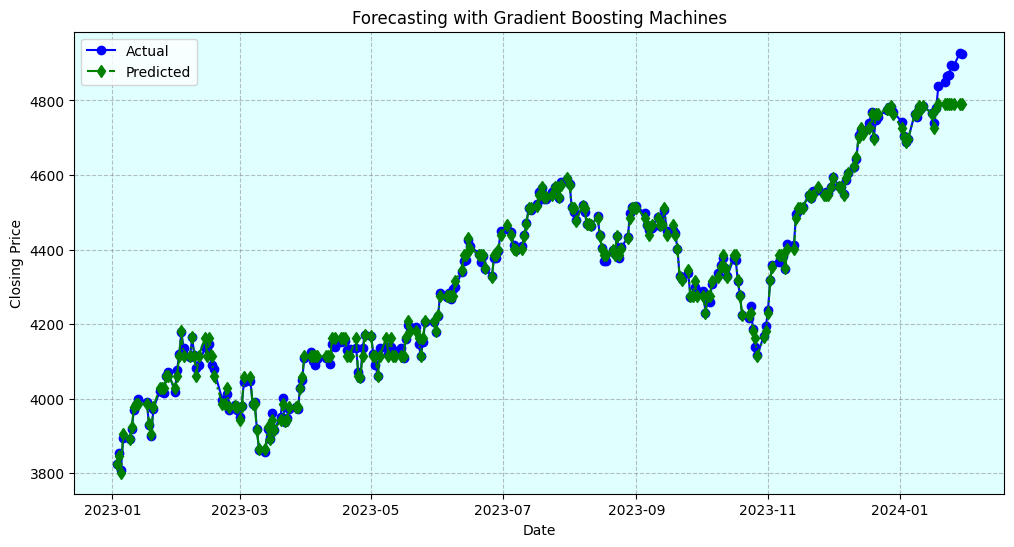

In [ ]:
!pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, mean_squared_log_error, r2_score
from sklearn.metrics import mean_squared_log_error, mean_squared_log_error, mean_squared_log_error


# Read the CSV file
data = pd.read_csv("sp500_historical_prices.csv")
data['Date'] = pd.to_datetime(data['Date'])

# Extract training and test data
train_data = data[(data['Date'] >= "2005-01-01") & (data['Date'] <= "2022-12-31")]
test_data = data[(data['Date'] >= "2023-01-01") & (data['Date'] <= "2024-01-31")]

# Select the closing price as the target variable
train_target = train_data['Close'].values
test_target = test_data['Close'].values

# Preprocess the data (scaling)
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data['Close'].values.reshape(-1, 1))
test_data_scaled = scaler.transform(test_data['Close'].values.reshape(-1, 1))

# Build the Gradient Boosting Regressor model
gbm_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
gbm_model.fit(train_data_scaled, train_target)

# Make predictions on the test data
predictions = gbm_model.predict(test_data_scaled)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(test_target, predictions))
mae = mean_absolute_error(test_target, predictions)
mape = mean_absolute_percentage_error(test_target, predictions) * 100
msle = mean_squared_log_error(test_target, predictions)
r_squared = r2_score(test_target, predictions)
mfe = np.mean(test_target - predictions)
mpe = mfe / np.mean(test_target)


# Print the evaluation metrics
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("Mean Absolute Percentage Error (MAPE):", mape, "%")
print("Mean Squared Logarithmic Error (MSLE):", msle)
print("R-squared Score:", r_squared)
print("Mean Forecast Error (MFE):", mfe)
print("Mean Percentage Error (MPE):", mpe)


# Plot the test data and predicted values
plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'], test_target, label='Actual', color='blue',linestyle='-', marker='o')
plt.plot(test_data['Date'], predictions, label='Predicted', color='green',linestyle='-.', marker='d')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Forecasting with Gradient Boosting Machines')
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.5, color='gray')
plt.gca().set_facecolor('#E0FFFF')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()
plt.show()



Random Forest

Root Mean Squared Error (RMSE): 16.13788035792327
Mean Absolute Error (MAE): 3.7799087366174446
Mean Absolute Percentage Error (MAPE): 0.07985841717818547 %
Mean Squared Logarithmic Error (MSLE): 1.1110803320924836e-05
R-squared Score: 0.996155649555157
Mean Forecast Error (MFE): 2.389233588324657
Mean Percentage Error (MPE): 0.0005527879642454484


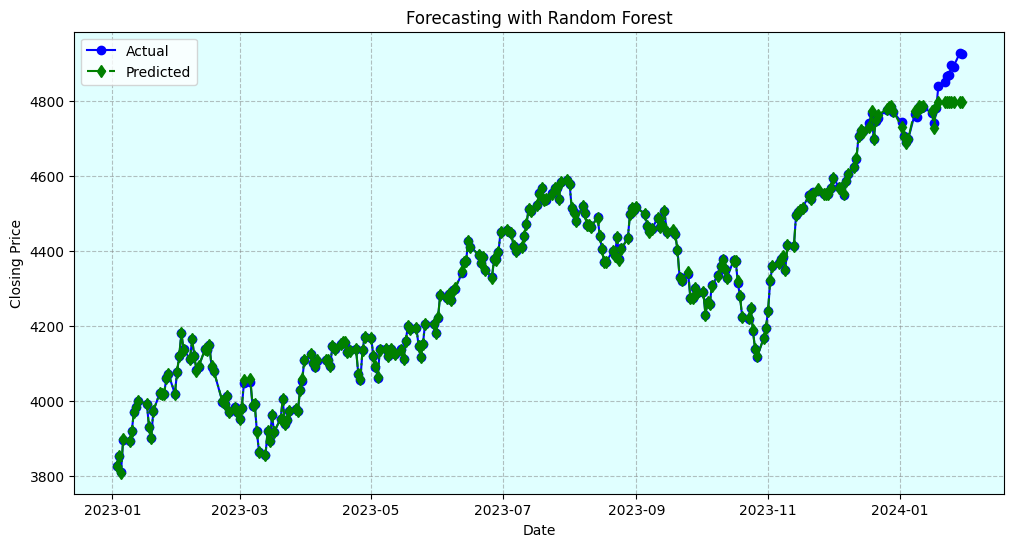

In [ ]:
!pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, mean_squared_log_error, r2_score
from sklearn.metrics import mean_squared_log_error, mean_squared_log_error, mean_squared_log_error


# Read the CSV file
data = pd.read_csv("sp500_historical_prices.csv")
data['Date'] = pd.to_datetime(data['Date'])

# Extract training and test data
train_data = data[(data['Date'] >= "2005-01-01") & (data['Date'] <= "2022-12-31")]
test_data = data[(data['Date'] >= "2023-01-01") & (data['Date'] <= "2024-01-31")]

# Select the closing price as the target variable
train_target = train_data['Close'].values
test_target = test_data['Close'].values

# Preprocess the data (scaling)
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data['Close'].values.reshape(-1, 1))
test_data_scaled = scaler.transform(test_data['Close'].values.reshape(-1, 1))

# Build the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(train_data_scaled, train_target)

# Make predictions on the test data
predictions = rf_model.predict(test_data_scaled)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(test_target, predictions))
mae = mean_absolute_error(test_target, predictions)
mape = mean_absolute_percentage_error(test_target, predictions) * 100
msle = mean_squared_log_error(test_target, predictions)
r_squared = r2_score(test_target, predictions)
mfe = np.mean(test_target - predictions)
mpe = mfe / np.mean(test_target)


# Print the evaluation metrics
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("Mean Absolute Percentage Error (MAPE):", mape, "%")
print("Mean Squared Logarithmic Error (MSLE):", msle)
print("R-squared Score:", r_squared)
print("Mean Forecast Error (MFE):", mfe)
print("Mean Percentage Error (MPE):", mpe)


# Plot the test data and predicted values
plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'], test_target, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(test_data['Date'], predictions, label='Predicted', color='green',linestyle='-.', marker='d')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Forecasting with Random Forest')
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.5, color='gray')
plt.gca().set_facecolor('#E0FFFF')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()
plt.show()






Bayesian Neural Network

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 51.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 80.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 50.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 16.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 28.9 MB/s eta 0:00:00
Root Mean Squared Err

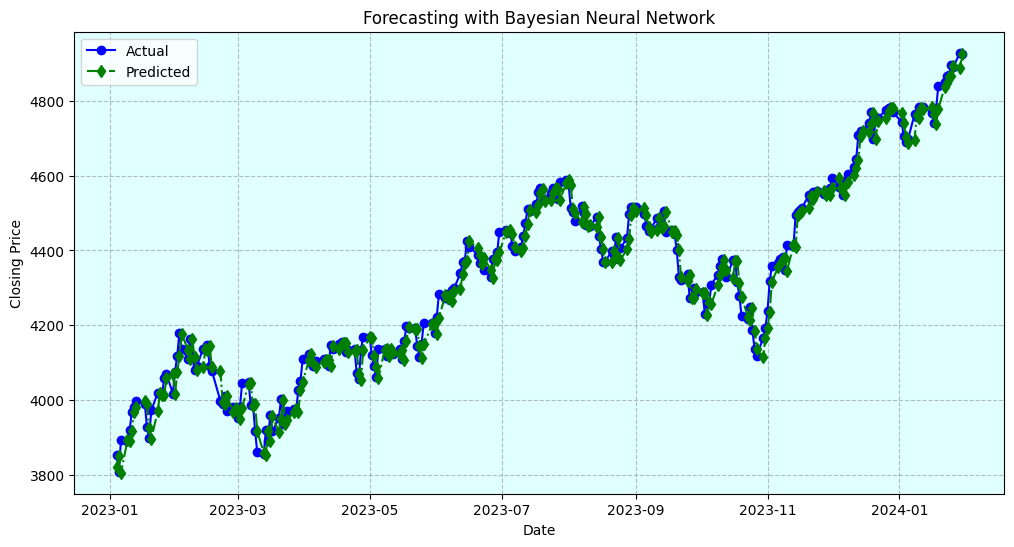

In [ ]:
!pip install torch numpy pandas matplotlib scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, mean_squared_log_error, r2_score


# Read the CSV file
data = pd.read_csv("sp500_historical_prices.csv")
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Extract training and test data
train_data = data["2005-01-01":"2022-12-31"]
test_data = data["2023-01-01":"2024-01-31"]

# Select the closing price as the target variable
train_target = train_data['Close'].values.reshape(-1, 1)
test_target = test_data['Close'].values.reshape(-1, 1)

# Normalize the data
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_target)
test_data_scaled = scaler.transform(test_target)

# Convert data to PyTorch tensors
X_train = torch.tensor(train_data_scaled[:-1], dtype=torch.float32)
y_train = torch.tensor(train_data_scaled[1:], dtype=torch.float32)
X_test = torch.tensor(test_data_scaled[:-1], dtype=torch.float32)
y_test = torch.tensor(test_data_scaled[1:], dtype=torch.float32)

# Define the Bayesian Neural Network model
class BayesianNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_samples=10):
        super(BayesianNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_samples = n_samples

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

        self.log_var = nn.Parameter(torch.Tensor(output_size))
        self.log_var.data.fill_(-6)  # Initialize log variance with a small negative value

    def forward(self, x):
        samples = []
        for _ in range(self.n_samples):
            h = torch.relu(self.fc1(x))
            y_pred = self.fc2(h)
            samples.append(y_pred)
        samples = torch.stack(samples, dim=0)  # Stack the samples
        return samples

    def calculate_log_likelihood(self, y_pred, y_true):
        log_likelihood = -0.5 * torch.exp(-self.log_var) * torch.square(y_true - y_pred)
        return log_likelihood

# Initialize the Bayesian Neural Network model
input_size = 1
hidden_size = 50
output_size = 1
n_samples = 100  # Number of Monte Carlo samples
learning_rate = 0.001
n_epochs = 1000

model = BayesianNN(input_size, hidden_size, output_size, n_samples)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(n_epochs):
    optimizer.zero_grad()
    y_pred = model(X_train)
    log_likelihood = model.calculate_log_likelihood(y_pred, y_train)
    loss = -log_likelihood.mean()  # Negative log-likelihood as loss
    loss.backward()
    optimizer.step()

# Generate predictions and calculate metrics
with torch.no_grad():
    y_pred_samples = model(X_test)
    y_pred_mean = y_pred_samples.mean(dim=0)
    predictions = scaler.inverse_transform(y_pred_mean.numpy())
    actual_values = scaler.inverse_transform(y_test.numpy())

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(actual_values, predictions))
mae = mean_absolute_error(actual_values, predictions)
mape = mean_absolute_percentage_error(actual_values, predictions) * 100
msle = mean_squared_log_error(actual_values, predictions)
r_squared = r2_score(actual_values, predictions)
mfe = np.mean(actual_values - predictions)
mpe = mfe / np.mean(actual_values)


# Print the evaluation metrics
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("Mean Absolute Percentage Error (MAPE):", mape, "%")
print("Mean Squared Logarithmic Error (MSLE):", msle)
print("R-squared Score:", r_squared)
print("Mean Forecast Error (MFE):", mfe)
print("Mean Percentage Error (MPE):", mpe)


# Plot the test data and predicted values
plt.figure(figsize=(12, 6))
plt.plot(test_data.index[1:], actual_values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(test_data.index[1:], predictions, label='Predicted', color='green',linestyle='-.', marker='d')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Forecasting with Bayesian Neural Network')
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.5, color='gray')
plt.gca().set_facecolor('#E0FFFF')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()
plt.show()







RNN

Epoch 1/50
140/140 [==============================] - 3s 13ms/step - loss: 0.0202
Epoch 2/50
140/140 [==============================] - 2s 12ms/step - loss: 6.2529e-05
Epoch 3/50
140/140 [==============================] - 1s 9ms/step - loss: 6.7829e-05
Epoch 4/50
140/140 [==============================] - 1s 8ms/step - loss: 6.8288e-05
Epoch 5/50
140/140 [==============================] - 1s 6ms/step - loss: 6.3856e-05
Epoch 6/50
140/140 [==============================] - 1s 6ms/step - loss: 6.4845e-05
Epoch 7/50
140/140 [==============================] - 1s 7ms/step - loss: 6.7208e-05
Epoch 8/50
140/140 [==============================] - 1s 6ms/step - loss: 6.3067e-05
Epoch 9/50
140/140 [==============================] - 1s 6ms/step - loss: 6.5797e-05
Epoch 10/50
140/140 [==============================] - 1s 6ms/step - loss: 6.6802e-05
Epoch 11/50
140/140 [==============================] - 1s 6ms/step - loss: 6.2644e-05
Epoch 12/50
140/140 [==============================] - 1s 6ms/ste

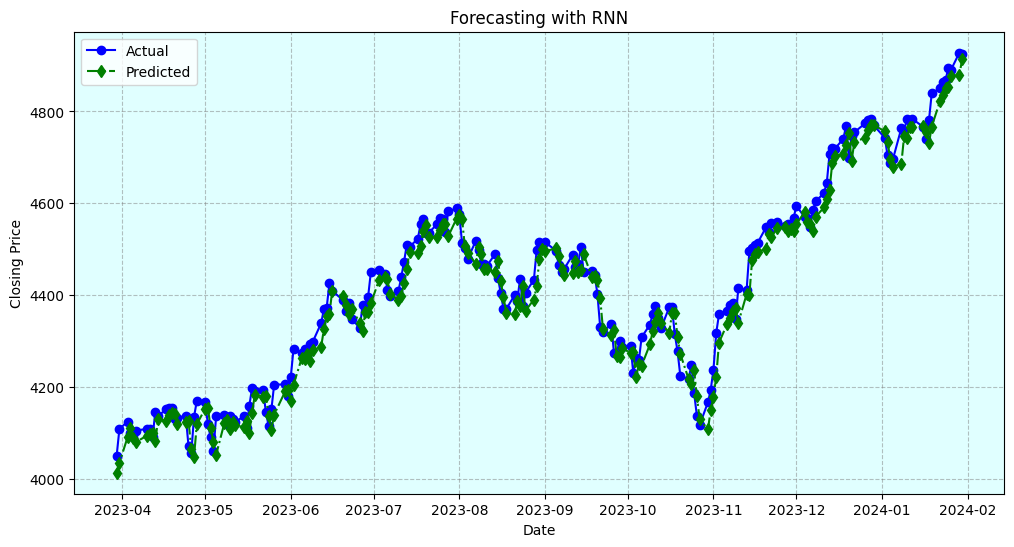

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, mean_squared_log_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

# Read the CSV file
data = pd.read_csv("sp500_historical_prices.csv")
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Extract the closing prices
closing_prices = data['Close'].values.reshape(-1, 1)

# Define training and test periods
train_end_date = "2022-12-31"
test_start_date = "2023-01-01"
test_end_date = "2024-01-31"

# Split the data into training and test sets
train_data = closing_prices[data.index <= train_end_date]
test_data = closing_prices[(data.index >= test_start_date) & (data.index <= test_end_date)]

# Normalize the data
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Define a function to create sequences from the data
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

# Create sequences for training and test data
sequence_length = 60  # You can adjust this based on your preference
X_train, y_train = create_sequences(train_data_scaled, sequence_length)
X_test, y_test = create_sequences(test_data_scaled, sequence_length)

# Build the RNN model
model = Sequential()
model.add(SimpleRNN(units=50, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(units=1))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

# Make predictions on the test data
predicted = model.predict(X_test)

# Inverse transform the predictions and target for evaluation
predicted = scaler.inverse_transform(predicted)
y_test = scaler.inverse_transform(y_test)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, predicted))
mae = mean_absolute_error(y_test, predicted)
mape = mean_absolute_percentage_error(y_test, predicted) * 100
msle = mean_squared_log_error(y_test, predicted)
r_squared = r2_score(y_test, predicted)
mfe = np.mean(y_test - predicted)
mpe = mfe / np.mean(y_test)


# Print the evaluation metrics
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("Mean Absolute Percentage Error (MAPE):", mape, "%")
print("Mean Squared Logarithmic Error (MSLE):", msle)
print("R-squared Score:", r_squared)
print("Mean Forecast Error (MFE):", mfe)
print("Mean Percentage Error (MPE):", mpe)


# Plot the test data and predicted values
plt.figure(figsize=(12, 6))
plt.plot(data.index[-len(y_test):], y_test, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(data.index[-len(y_test):], predicted, label='Predicted', color='green', linestyle='-.', marker='d')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.title('Forecasting with RNN')
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.5, color='gray')
plt.gca().set_facecolor('#E0FFFF')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()
plt.show()





LSTM

Epoch 1/50
140/140 [==============================] - 3s 14ms/step - loss: 0.0106
Epoch 2/50
140/140 [==============================] - 2s 14ms/step - loss: 1.5745e-04
Epoch 3/50
140/140 [==============================] - 2s 14ms/step - loss: 1.4219e-04
Epoch 4/50
140/140 [==============================] - 2s 14ms/step - loss: 1.3389e-04
Epoch 5/50
140/140 [==============================] - 2s 16ms/step - loss: 1.2944e-04
Epoch 6/50
140/140 [==============================] - 2s 14ms/step - loss: 1.2572e-04
Epoch 7/50
140/140 [==============================] - 2s 14ms/step - loss: 1.1610e-04
Epoch 8/50
140/140 [==============================] - 2s 14ms/step - loss: 1.1635e-04
Epoch 9/50
140/140 [==============================] - 2s 14ms/step - loss: 1.2304e-04
Epoch 10/50
140/140 [==============================] - 2s 16ms/step - loss: 1.2262e-04
Epoch 11/50
140/140 [==============================] - 2s 15ms/step - loss: 1.0643e-04
Epoch 12/50
140/140 [==============================] - 2

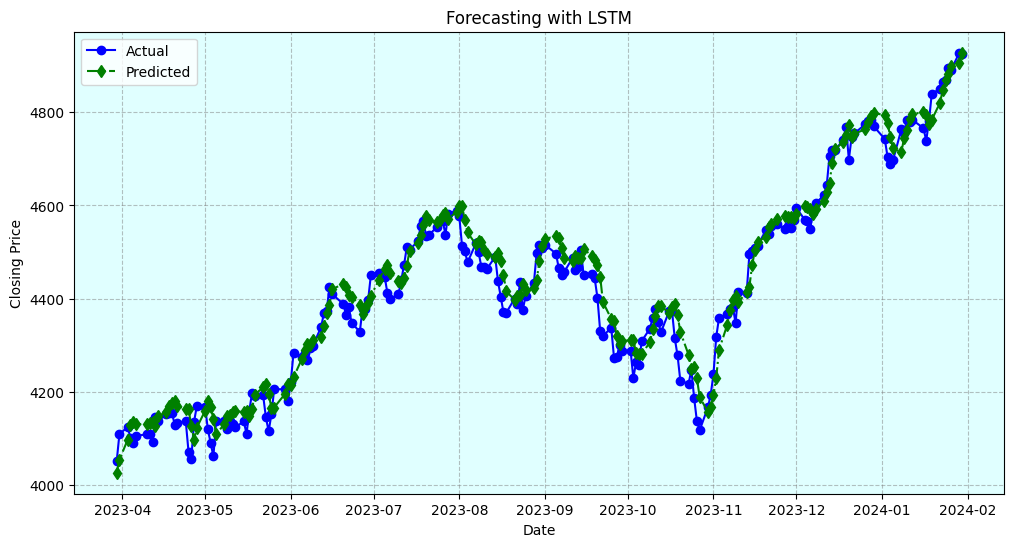

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, mean_squared_log_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Read the CSV file
data = pd.read_csv("sp500_historical_prices.csv")
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Extract the closing prices
closing_prices = data['Close'].values.reshape(-1, 1)

# Define training and test periods
train_end_date = "2022-12-31"
test_start_date = "2023-01-01"
test_end_date = "2024-01-31"

# Split the data into training and test sets
train_data = closing_prices[data.index <= train_end_date]
test_data = closing_prices[(data.index >= test_start_date) & (data.index <= test_end_date)]

# Normalize the data
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Define a function to create sequences from the data
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

# Create sequences for training and test data
sequence_length = 60  # You can adjust this based on your preference
X_train, y_train = create_sequences(train_data_scaled, sequence_length)
X_test, y_test = create_sequences(test_data_scaled, sequence_length)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(units=1))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

# Make predictions on the test data
predicted = model.predict(X_test)

# Inverse transform the predictions and target for evaluation
predicted = scaler.inverse_transform(predicted)
y_test = scaler.inverse_transform(y_test)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, predicted))
mae = mean_absolute_error(y_test, predicted)
mape = mean_absolute_percentage_error(y_test, predicted) * 100
msle = mean_squared_log_error(y_test, predicted)
r_squared = r2_score(y_test, predicted)
mfe = np.mean(y_test - predicted)
mpe = mfe / np.mean(y_test)


# Print the evaluation metrics
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("Mean Absolute Percentage Error (MAPE):", mape, "%")
print("Mean Squared Logarithmic Error (MSLE):", msle)
print("R-squared Score:", r_squared)
print("Mean Forecast Error (MFE):", mfe)
print("Mean Percentage Error (MPE):", mpe)


# Plot the test data and predicted values
plt.figure(figsize=(12, 6))
plt.plot(data.index[-len(y_test):], y_test, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(data.index[-len(y_test):], predicted, label='Predicted', color='green', linestyle='-.', marker='d')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.title('Forecasting with LSTM')
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.5, color='gray')
plt.gca().set_facecolor('#E0FFFF')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()
plt.show()




DNN

Epoch 1/100
142/142 [==============================] - 1s 1ms/step - loss: 0.0125
Epoch 2/100
142/142 [==============================] - 0s 1ms/step - loss: 4.6226e-05
Epoch 3/100
142/142 [==============================] - 0s 1ms/step - loss: 4.6075e-05
Epoch 4/100
142/142 [==============================] - 0s 1ms/step - loss: 4.7059e-05
Epoch 5/100
142/142 [==============================] - 0s 1ms/step - loss: 4.7375e-05
Epoch 6/100
142/142 [==============================] - 0s 1ms/step - loss: 4.7390e-05
Epoch 7/100
142/142 [==============================] - 0s 1ms/step - loss: 5.3262e-05
Epoch 8/100
142/142 [==============================] - 0s 1ms/step - loss: 5.0775e-05
Epoch 9/100
142/142 [==============================] - 0s 1ms/step - loss: 4.9418e-05
Epoch 10/100
142/142 [==============================] - 0s 1ms/step - loss: 5.0086e-05
Epoch 11/100
142/142 [==============================] - 0s 1ms/step - loss: 5.5226e-05
Epoch 12/100
142/142 [==============================] - 

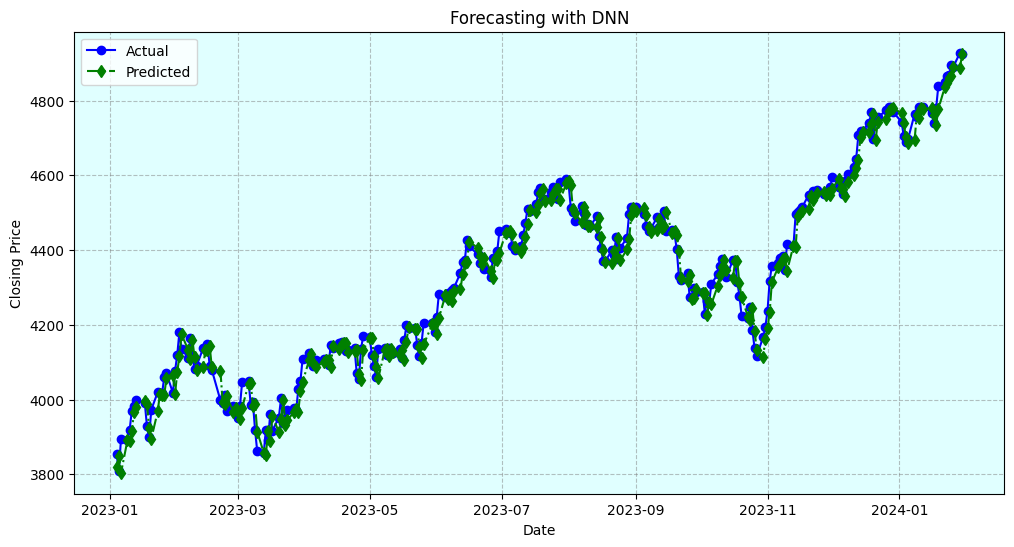

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, mean_squared_log_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Read the CSV file
data = pd.read_csv("sp500_historical_prices.csv")
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Extract the closing prices
closing_prices = data['Close'].values.reshape(-1, 1)

# Define training and test periods
train_end_date = "2022-12-31"
test_start_date = "2023-01-01"
test_end_date = "2024-01-31"

# Split the data into training and test sets
train_data = closing_prices[data.index <= train_end_date]
test_data = closing_prices[(data.index >= test_start_date) & (data.index <= test_end_date)]

# Normalize the data
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Define the neural network model (deep)
model = Sequential()
model.add(Dense(units=128, activation='relu', input_shape=(1,)))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Define X_train, y_train, X_test, y_test
X_train = train_data_scaled[:-1]
y_train = train_data_scaled[1:]
X_test = test_data_scaled[:-1]
y_test = test_data_scaled[1:]

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

# Make predictions on the test data
predictions = model.predict(X_test)

# Inverse transform the predictions and target for evaluation
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions) * 100
msle = mean_squared_log_error(y_test, predictions)
r_squared = r2_score(y_test, predictions)
mfe = np.mean(y_test - predictions)
mpe = mfe / np.mean(y_test)

# Print the evaluation metrics
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("Mean Absolute Percentage Error (MAPE):", mape, "%")
print("Mean Squared Logarithmic Error (MSLE):", msle)
print("R-squared Score:", r_squared)
print("Mean Forecast Error (MFE):", mfe)
print("Mean Percentage Error (MPE):", mpe)

# Plot the test data and predicted values
plt.figure(figsize=(12, 6))
plt.plot(data.index[-len(y_test):], y_test, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(data.index[-len(y_test):], predictions, label='Predicted', color='green', linestyle='-.', marker='d')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.title('Forecasting with DNN')
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.5, color='gray')
plt.gca().set_facecolor('#E0FFFF')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()
plt.show()





